<a href="https://colab.research.google.com/github/jyotinayak321/IBM-ML-Training/blob/main/Decision_Tree_ibm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dession Tree in ML**

is a supervised learning ML algo used for both **classification** and **regresion tasks**

-> it consists of a hierarchal str which consists of a root node ,branches ,internal node and leaf node

-> internal ode represent attribute tests

-> branches represent attributes values

-> leaf node represent final decision /prediction


# **Dession Tree what does**
# *it split the data set into feature value to create pure subsets*




# ***Spliting critieria in DT***
## which feature to split at each node the 2 most coommon criteria are Gini **index** and **Entropy**

# **Gini Impurity**: Gini Impurity tells us how likely it is that a randomly chosen data point would be incorrectly classified if it were labeled according to the distribution of classes in that node.
                 Gini=1−∑pi2​        ,where pi= proportion of particular class ka proportion

                 , pi = total data of classes / total data

Example 1: Pure Node ✅

Suppose a node has:

Pass = 10
Fail = 0

All observations belong to one class.

So:

Gini Impurity = 0

 Gini = 0 means the node is completely pure.


 notes: it tell how the mix the casses is.     

 ------------------------------------------------------------

 Impact after Splitting in Decision Tree

When a Decision Tree splits a node, its goal is to make the resulting child nodes more pure (less mixed)  

Suppose before splitting:

Parent Node
10 students
Pass = 5
Fail = 5

Gini = 0.50

Now we split based on Study Hours > 3:

              Parent
             5 Pass
             5 Fail
               |
        Study Hours > 3
          /          \
       Child 1      Child 2
       4 Pass       1 Pass
       1 Fail       4 Fail

For each child, we calculate Gini.

Child 1
Gini=1−(4/5)
2
−(1/5)
2
=1−0.64−0.04=0.32
Child 2
Gini=1−(1/5)
2
−(4/5)
2
=0.32

So after splitting, the child nodes have lower impurity (0.32) than the parent node (0.50)

# **Entropy(S)** :  measure of randomness(Entropy tells us how uncertain or mixed the classes are in a node.).

Entropy = ∑pi ​log2​pi​

# Entropy = 0 → Completely pure
# Higher entropy → More uncertainty/mixing

#Higher Information Gain = Better split.

# **🌳 Pruning in Decision Tree**
Pruning means removing unnecessary branches from a Decision Tree to make the tree simpler and reduce overfitting.

**Why do we use pruning?**
To reduce overfitting and improve the model's ability to generalize to unseen data.

**Two types of pruning**:
1. Pre-pruning : We stop the tree from growing too much in the first place.
2. Post-pruning :First, we allow the tree to grow, and then remove unnecessary branches.




# **Tree too big → Overfitting → Pruning → Smaller tree → Better generalization.**

# **Dataset → Train-Test Split → Preprocessing → Decision Tree → Gini/Entropy → Best Split → Tree Growth → Pruning → Prediction → Evaluation**


Using Colab cache for faster access to the 'drug-classification' dataset.
Accuracy: 0.475


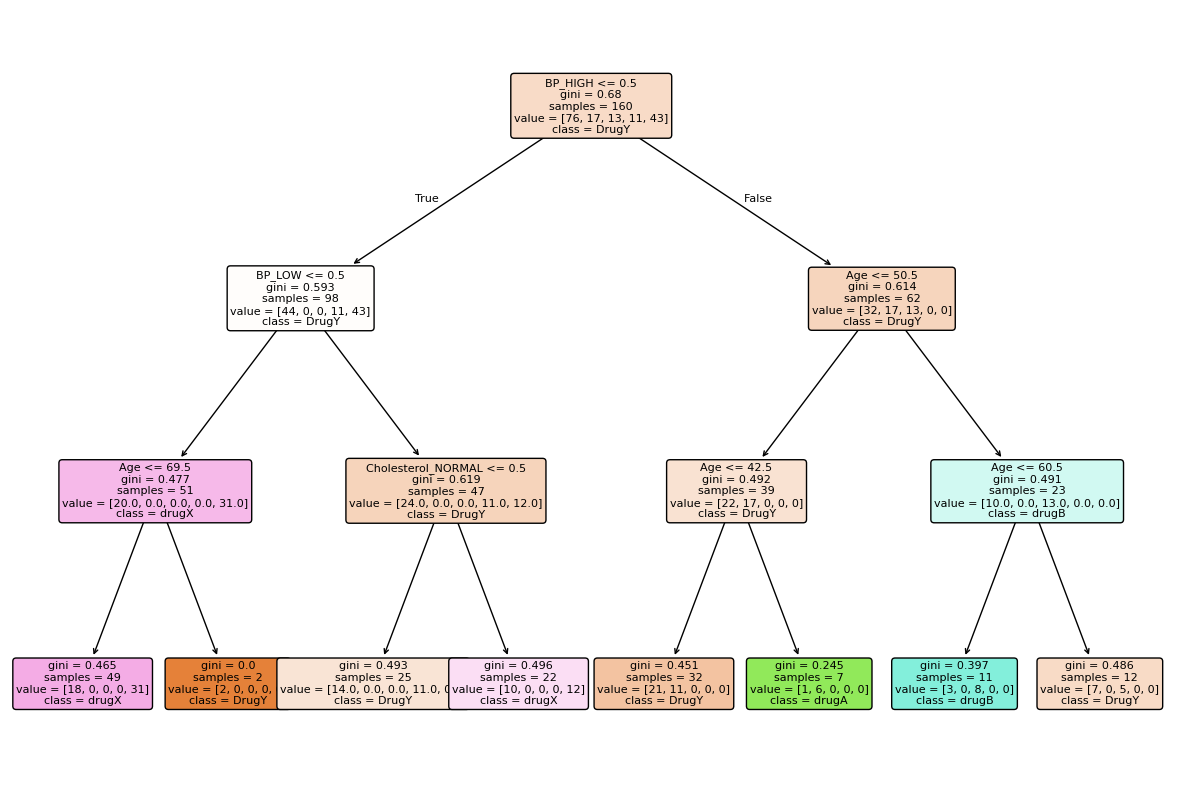

In [1]:
import numpy as np
import pandas as pd
import kagglehub
import os
path = kagglehub.dataset_download(
    "prathamtripathi/drug-classification")
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

#read data
df = pd.read_csv(os.path.join(path,"drug200.csv"))
df.head()
df.columns
df.drop(columns =['Na_to_K'])

#feature & targets
X = df[['Age','Sex','BP','Cholesterol']]
y = df['Drug']

X_encoded = pd.get_dummies(X,columns=['Sex','BP','Cholesterol'])

#X_encoding converts categorical columns into numerical
#columns before giving data to  ML model like DT

#split the dataset
X_train,X_test,y_train,y_test = train_test_split(X_encoded,y,test_size=0.2,random_state=42)

#create the model
model = DecisionTreeClassifier(max_depth=3,random_state=42)
model.fit(X_train,y_train)

#Prediction
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test,y_pred))

#plot tree
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize = (15,10))
tree.plot_tree(model,feature_names = X_encoded.columns,class_names = model.classes_.astype(str), filled =True,rounded = True, fontsize = 8)
plt.show()

